In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Directories
BASE_CRM = Path("/media/dysco/New Volume/Neeraj/varflexi solver/results/best_result_crm")
BASE_RES = Path("/media/dysco/New Volume/Neeraj/varflexi solver/results/results 2/results-reisner-span")

FIG_DIR = Path("/home/dysco/FLOWUnsteady/VarFLEXI-rVPM-Fenics/FINAL/notebooks/plots/comparison")
FIG_DIR.mkdir(parents=True, exist_ok=True)

# Helper to get subdirectories assuming identical structure
def get_dirs(base_path):
    return {
        "solid": base_path / "solid" / "v18_reissner_mindlin_plate",
        "fluid": base_path / "fluid" / "v9",
        "coupling": base_path / "coupling"
    }

dirs_crm = get_dirs(BASE_CRM)
dirs_res = get_dirs(BASE_RES)

# Plot settings
plt.rcParams.update({
    "font.family": "serif", "mathtext.fontset": "cm", "font.size": 10,
    "axes.labelsize": 10, "axes.titlesize": 10, "legend.fontsize": 9, 
    "xtick.labelsize": 8, "ytick.labelsize": 8, "lines.linewidth": 1.2, 
    "axes.linewidth": 0.8, "figure.dpi": 300, "savefig.bbox": "tight"
})

# Load the core diagnostic files for BOTH cases
solid_crm = pd.read_csv(dirs_crm["solid"] / "solid_v18_diagnostics.csv")
fluid_coupling_crm = pd.read_csv(dirs_crm["fluid"] / "fluid_v9_coupling_diagnostics.csv")

solid_res = pd.read_csv(dirs_res["solid"] / "solid_v18_diagnostics.csv")
fluid_coupling_res = pd.read_csv(dirs_res["fluid"] / "fluid_v9_coupling_diagnostics.csv")

print("Both diagnostic datasets loaded successfully.")

Both diagnostic datasets loaded successfully.


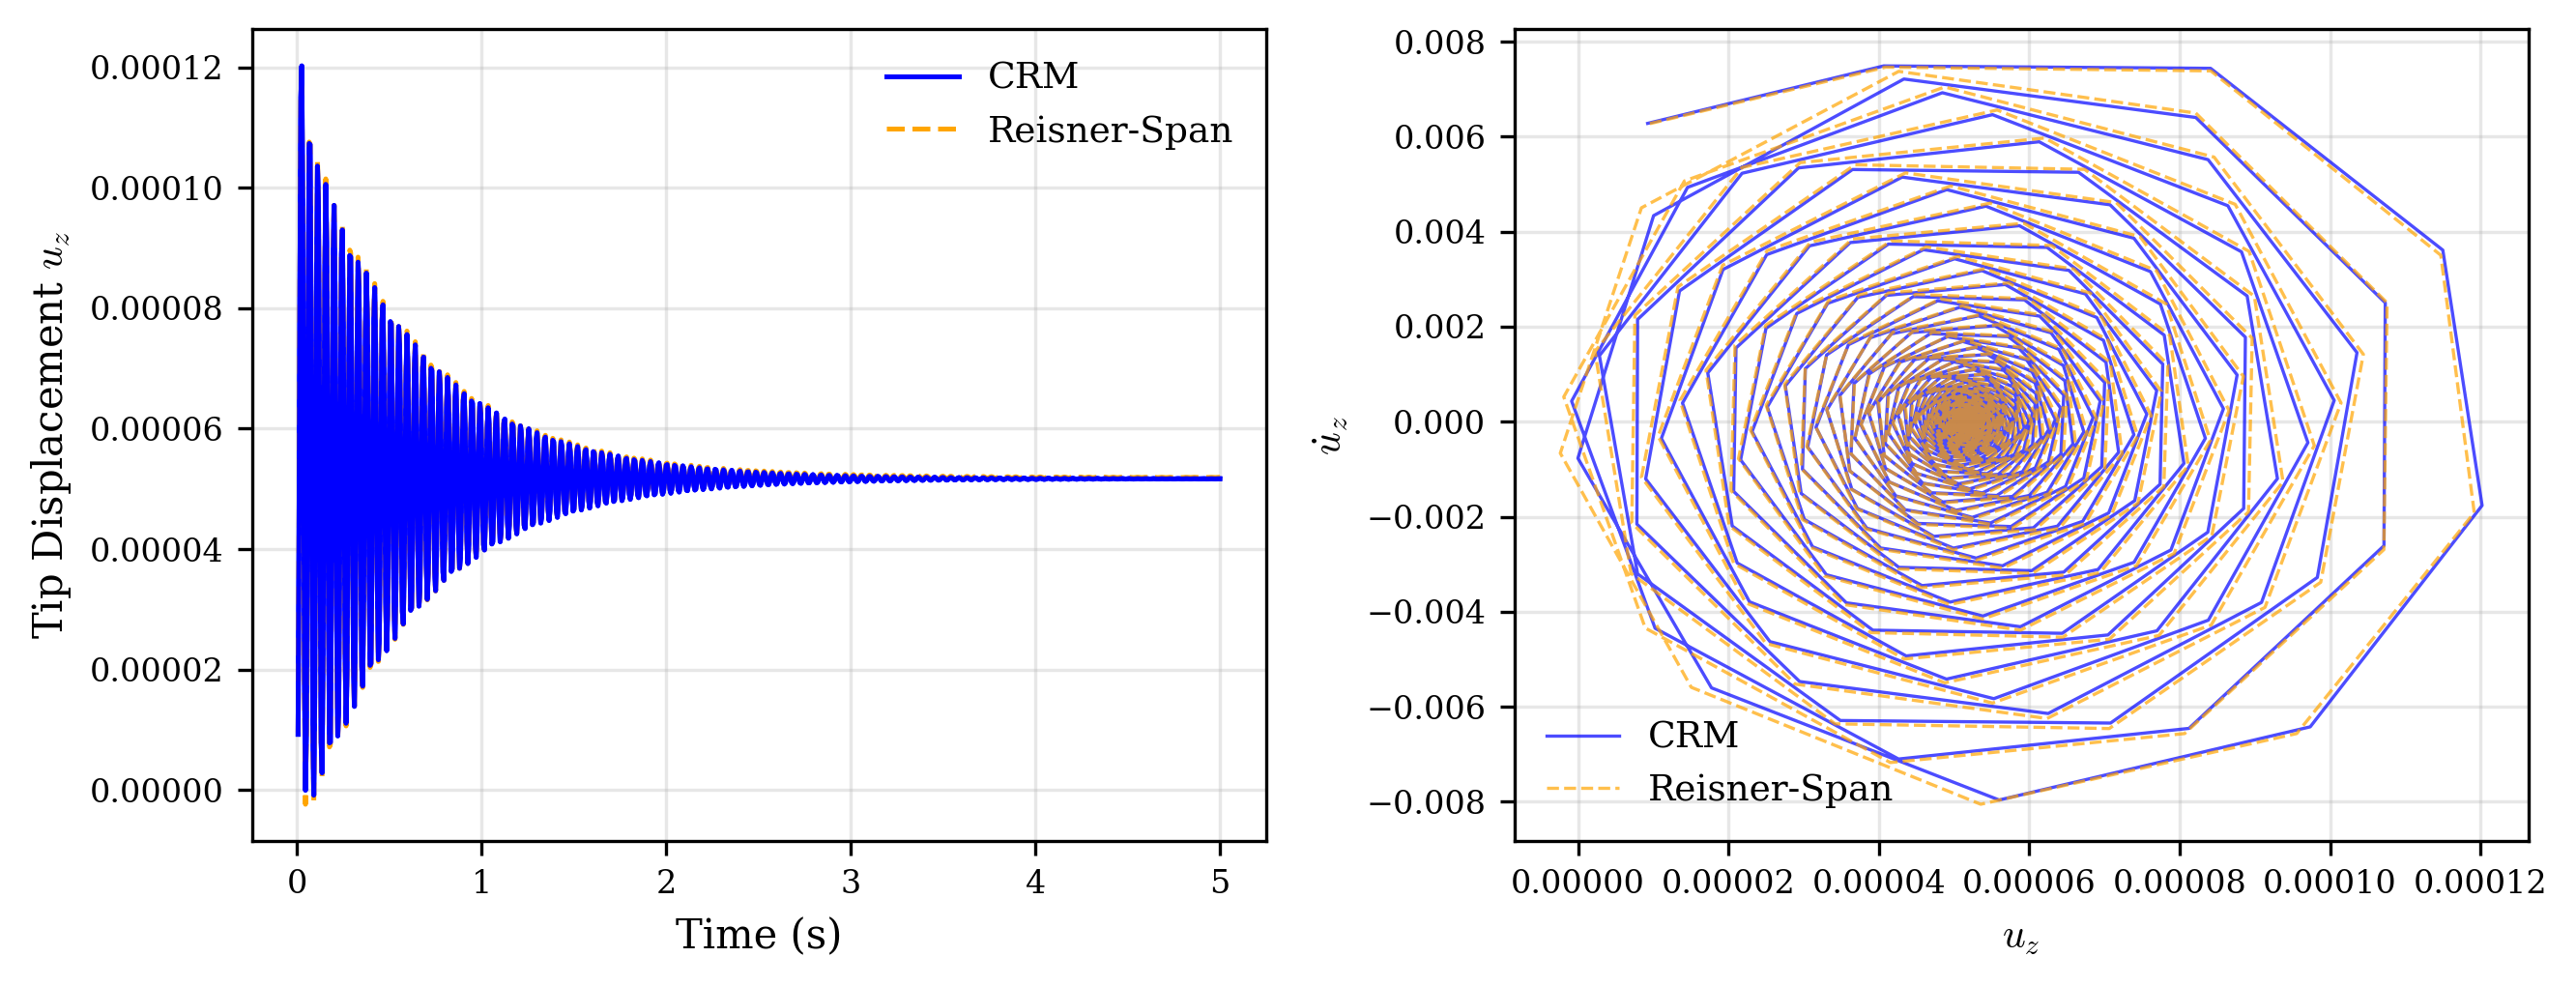

In [2]:
# Extract CRM data
time_crm = solid_crm['time'].values
u_tip_crm = solid_crm['u_tip'].values
v_tip_crm = np.gradient(u_tip_crm, time_crm)

# Extract Reisner-Span data
time_res = solid_res['time'].values
u_tip_res = solid_res['u_tip'].values
v_tip_res = np.gradient(u_tip_res, time_res)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9, 3.5))

# Plot 1: Displacement Time History
ax1.plot(time_crm, u_tip_crm, color='b', linestyle='-', label='CRM')
ax1.plot(time_res, u_tip_res, color='orange', linestyle='--', label='Reisner-Span')
ax1.set_xlabel(r"Time (s)")
ax1.set_ylabel(r"Tip Displacement $u_z$")
ax1.grid(True, alpha=0.3)
# plt.xlim(4,5)
ax1.legend(frameon=False)

# Plot 2: Phase Space
ax1.plot(time_crm, u_tip_crm, color='b', linestyle='-', label='CRM')
ax2.plot(u_tip_crm, v_tip_crm, color='b', linestyle='-', linewidth=0.8, alpha=0.7, label='CRM')
ax2.plot(u_tip_res, v_tip_res, color='orange', linestyle='--', linewidth=0.8, alpha=0.7, label='Reisner-Span')
ax2.set_xlabel(r"$u_z$")
ax2.set_ylabel(r"$\dot{u}_z$")
ax2.grid(True, alpha=0.3)
# plt.xlim(4,5)
ax2.legend(frameon=False)

fig.tight_layout()
fig.savefig(FIG_DIR / "comparison_kinematics.pdf")
plt.show()

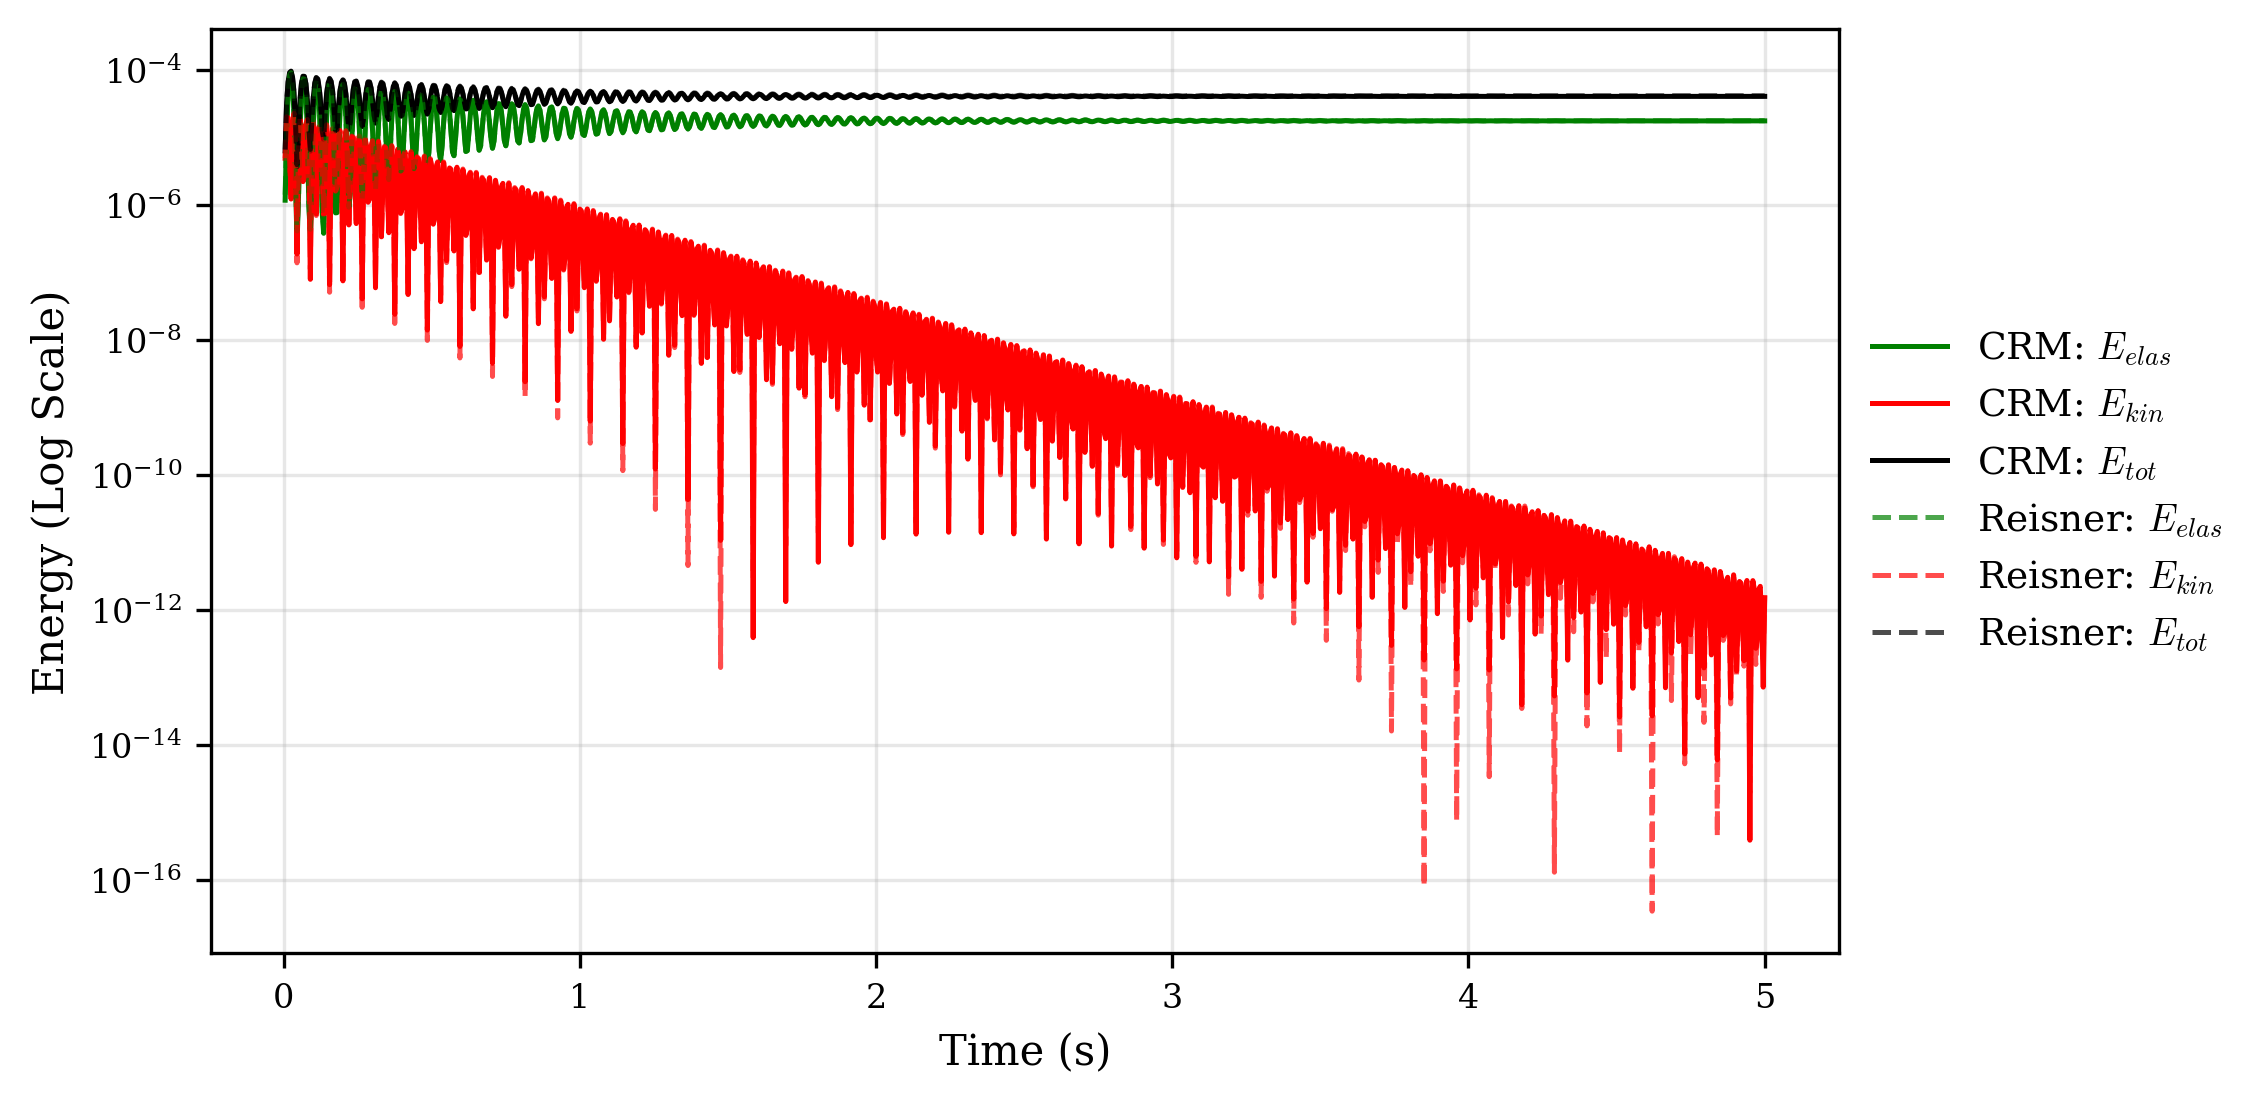

In [3]:
fig, ax = plt.subplots(figsize=(7, 4))

# Plot CRM (Solid lines)
ax.semilogy(time_crm, solid_crm['E_elas'], color='g', linestyle='-', label=r"CRM: $E_{elas}$")
ax.semilogy(time_crm, solid_crm['E_kin'], color='r', linestyle='-', label=r"CRM: $E_{kin}$")
ax.semilogy(time_crm, solid_crm['E_tot'], color='k', linestyle='-', label=r"CRM: $E_{tot}$")

# Plot Reisner-Span (Dashed lines)
ax.semilogy(time_res, solid_res['E_elas'], color='g', linestyle='--', alpha=0.7, label=r"Reisner: $E_{elas}$")
ax.semilogy(time_res, solid_res['E_kin'], color='r', linestyle='--', alpha=0.7, label=r"Reisner: $E_{kin}$")
ax.semilogy(time_res, solid_res['E_tot'], color='k', linestyle='--', alpha=0.7, label=r"Reisner: $E_{tot}$")

ax.set_xlabel(r"Time (s)")
ax.set_ylabel(r"Energy (Log Scale)")
ax.grid(True, which="both", alpha=0.3)

# Place legend outside to avoid cluttering the plot
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), frameon=False)

fig.savefig(FIG_DIR / "comparison_energy_log.pdf", bbox_inches='tight')
plt.show()

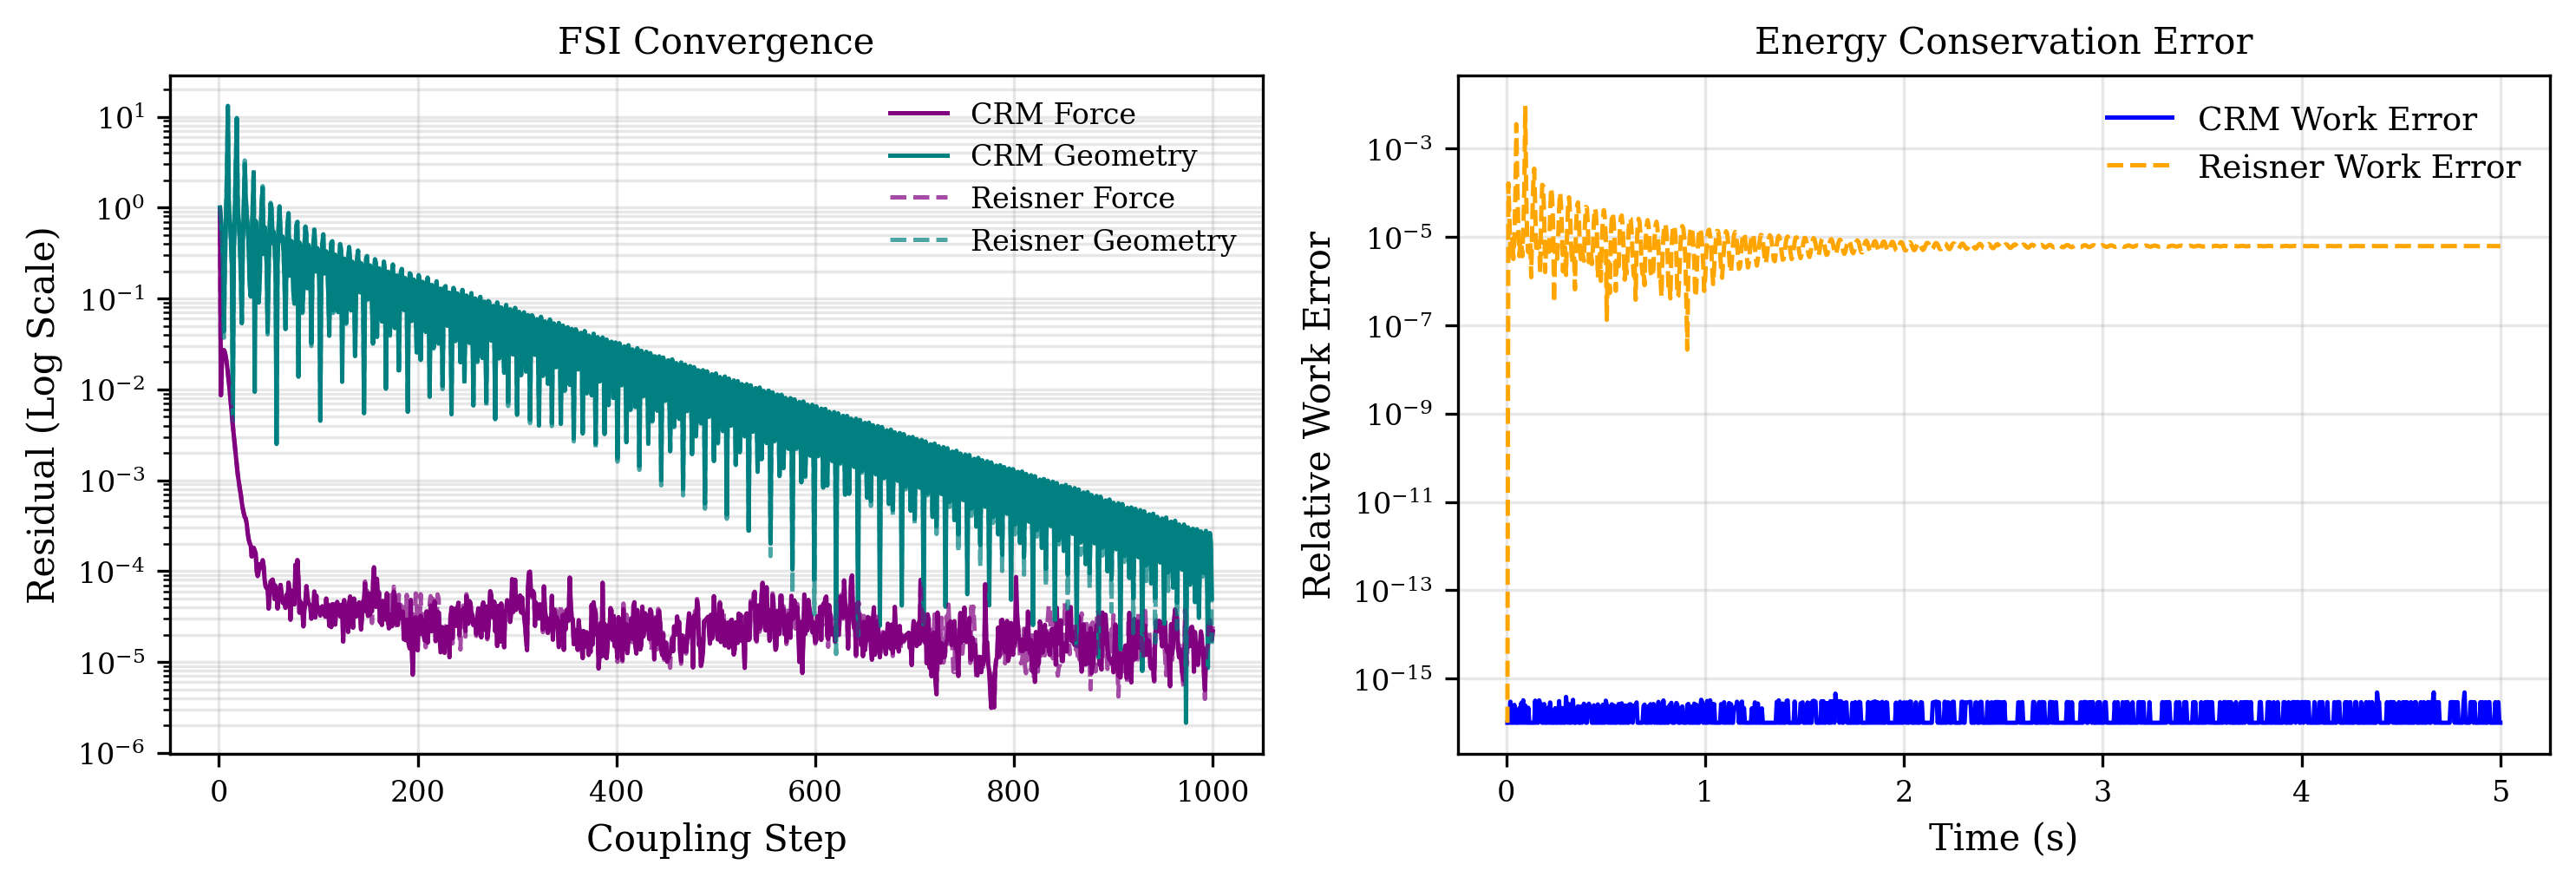

In [4]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3.5))

# Plot 1: FSI Coupling Residuals
ax1.semilogy(fluid_coupling_crm['step'], fluid_coupling_crm['force_residual'], color='purple', linestyle='-', label='CRM Force')
ax1.semilogy(fluid_coupling_crm['step'], fluid_coupling_crm['geometry_residual'], color='teal', linestyle='-', label='CRM Geometry')

ax1.semilogy(fluid_coupling_res['step'], fluid_coupling_res['force_residual'], color='purple', linestyle='--', alpha=0.7, label='Reisner Force')
ax1.semilogy(fluid_coupling_res['step'], fluid_coupling_res['geometry_residual'], color='teal', linestyle='--', alpha=0.7, label='Reisner Geometry')

ax1.set_xlabel(r"Coupling Step")
ax1.set_ylabel(r"Residual (Log Scale)")
ax1.set_title("FSI Convergence")
ax1.grid(True, which="both", alpha=0.3)
ax1.legend(fontsize=8, frameon=False)

# Plot 2: Solid Solver Work Error
ax2.semilogy(time_crm, solid_crm['work_rel_error'] + 1e-16, color='b', linestyle='-', label='CRM Work Error')
ax2.semilogy(time_res, solid_res['work_rel_error'] + 1e-16, color='orange', linestyle='--', label='Reisner Work Error')

ax2.set_xlabel(r"Time (s)")
ax2.set_ylabel(r"Relative Work Error")
ax2.set_title("Energy Conservation Error")
ax2.grid(True, which="both", alpha=0.3)
ax2.legend(frameon=False)

fig.tight_layout()
fig.savefig(FIG_DIR / "comparison_solver_diagnostics_log.pdf")
plt.show()